With the w2 (=Fvoigt) functions calculated earlier, let's see what ratios we obtain

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lace.cosmo import camb_cosmo
from forestflow.model_p3d_arinyo import ArinyoModel
from picca import constants
import camb

In [2]:
# MW21 cosmology values
hubble, z = 0.71, 2.5
omegab, omegam = 0.046, 0.27
omegal = 1 - omegam
ns = 0.96

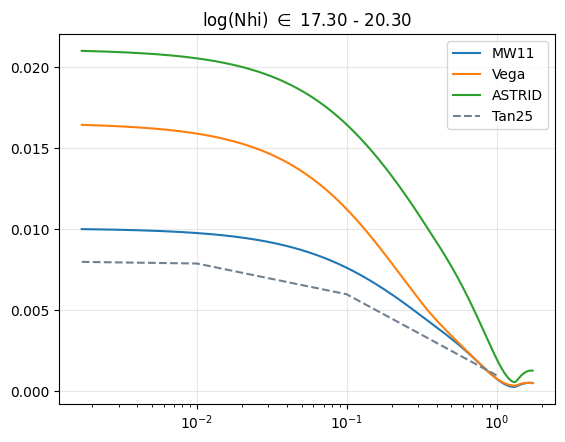

In [3]:
data = np.loadtxt('w2_functions.txt')
k_los, w2_vega, w2_astrid, w2_MW11, w1_MW11 = data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]
NHirange = np.logspace(np.log10(17.3), np.log10(20.3))

plt.plot(k_los, w2_MW11, label='MW11')
plt.plot(k_los, w2_vega, label='Vega')
plt.plot(k_los, w2_astrid, label='ASTRID')
plt.plot([k_los.min(), 1e-2, 1e-1, 1], [0.008, 0.0079, 0.006, 0.001], color='slategrey', linestyle='--', label='Tan25')
plt.legend()
plt.xscale('log')
plt.grid(alpha=0.3)
plt.title(r'log(Nhi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));


# Plin

In [4]:
from camb import model
pars = camb.set_params(H0=100*hubble, ombh2=omegab*(hubble**2), omch2=omegam*(hubble**2), ns=ns)
pars.set_matter_power(redshifts=[z], kmax=100)
pars.NonLinear = model.NonLinear_none  # Linear spectra
results = camb.get_results(pars)
k_lin, z, pk = results.get_linear_matter_power_spectrum(hubble_units=False, k_hunit=False, ) 

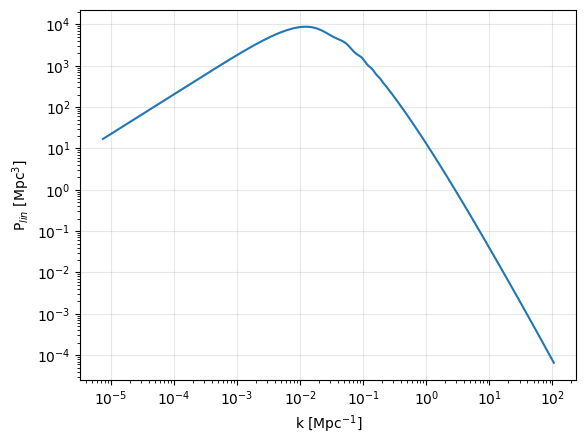

In [5]:
plt.plot(k_lin, pk[0, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{lin}$ [Mpc$^{3}$]');

# P3D

In [6]:
bias_hcd = 2
mu = np.linspace(0, 1, 11)

Using mu and k_los from W1 and W2 we can define k

In [7]:
# k_max = k_los.max()/mu.min() This would be infinite
k_max = 40  # Mpc^-1
k_min = k_los.min()/mu.max()
print('k values can range from', k_min, 'to', k_max, 'Mpc^-1')
k = np.logspace(np.log10(k_min), np.log10(k_max), len(k_los))  # New k array

k values can range from 0.001702895 to 40 Mpc^-1


We should resample linear matter power spectrum into the new k array

In [8]:
plin = np.interp(k, k_lin, pk[0, :], right=np.nan, left=np.nan)  # Plin values in that new k array
del k_lin, pk

And calculate P3D:

In [9]:
P3d_hcd_MW11 = []
for mu_value in mu:
    if mu_value == 0:  # k_los = 0. We assume that w2[klos=0]= w2[klos.min]
        w2_k_mu = w2_MW11[0]
    else:
        k_los_mu = k * mu_value  # Given mu, the k_los values associated to k
        w2_k_mu = np.interp(k_los_mu, k_los, w2_MW11, left=np.nan, right=np.nan)  # We evaluate the function w2 in those k_los_mu values
    Pf_mu = (w2_k_mu**2)*((bias_hcd + mu_value**2)**2)*plin
    P3d_hcd_MW11.append(Pf_mu)

P3d_hcd_MW11 = np.array(P3d_hcd_MW11)

In [10]:
P3d_hcd_astrid = []
for mu_value in mu:
    if mu_value == 0:  # k_los = 0. We assume that w2[klos=0]= w2[klos.min]
        w2_k_mu = w2_astrid[0]
    else:
        k_los_mu = k * mu_value  # Given mu, the k_los values associated to k
        w2_k_mu = np.interp(k_los_mu, k_los, w2_astrid, left=np.nan, right=np.nan)  # We evaluate the function w2 in those k_los_mu values
    Pf_mu = (w2_k_mu**2)*((bias_hcd + mu_value**2)**2)*plin
    P3d_hcd_astrid.append(Pf_mu)

P3d_hcd_astrid = np.array(P3d_hcd_astrid)

In [11]:
P3d_hcd_vega = []
for mu_value in mu:
    if mu_value == 0:  # k_los = 0. We assume that w2[klos=0]= w2[klos.min]
        w2_k_mu = w2_vega[0]
    else:
        k_los_mu = k * mu_value  # Given mu, the k_los values associated to k
        w2_k_mu = np.interp(k_los_mu, k_los, w2_vega, left=np.nan, right=np.nan)  # We evaluate the function w2 in those k_los_mu values
    Pf_mu = (w2_k_mu**2)*((bias_hcd + mu_value**2)**2)*plin
    P3d_hcd_vega.append(Pf_mu)

P3d_hcd_vega = np.array(P3d_hcd_vega)

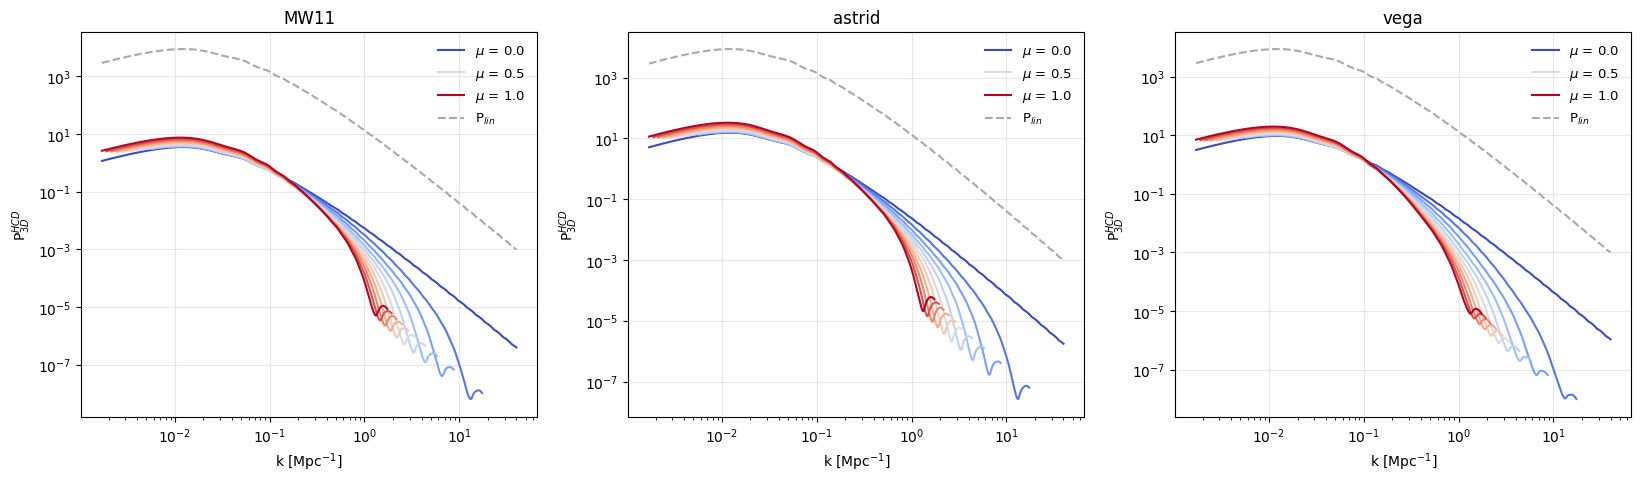

In [12]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, P3d_hcd_MW11[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, P3d_hcd_MW11[i, :])
plt.plot(k, plin, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$')
plt.title('MW11');

plt.subplot(1, 3, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, P3d_hcd_astrid[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, P3d_hcd_astrid[i, :])
plt.plot(k, plin, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$')
plt.title('astrid');

plt.subplot(1, 3, 3)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, P3d_hcd_vega[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, P3d_hcd_vega[i, :])
plt.plot(k, plin, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$')
plt.title('vega');


# Arinyo model

In [13]:
from forestflow.model_p3d_arinyo import ArinyoModel
zs = np.array([2.5]) # set target redshift
cosmo = camb_cosmo.get_cosmology(H0=100*hubble, omch2=0.27*(hubble**2), ombh2=0.046*(hubble**2), ns=0.96)  # MW21 cosmology
camb_results = camb_cosmo.get_camb_results(cosmo, zs=zs, camb_kmax_Mpc=200) # set default cosmo
arinyo = ArinyoModel(cosmo=cosmo, camb_results=camb_results, zs=zs, camb_kmax_Mpc=200, default_bias=-0.18, default_beta=1) # set MW21 model
arinyo.default_params

{'bias': -0.18,
 'beta': 1,
 'q1': 0.4,
 'q2': 0.0,
 'kvav': 0.58,
 'av': 0.29,
 'bv': 1.55,
 'kp': 10.5}

In [14]:
mu = np.linspace(0, 1, 11)

In [15]:
nn_k = len(k) # number of k bins
nn_mu = len(mu) # number of mu bins
k2d = np.tile(k[:, np.newaxis], nn_mu) # k grid for P3D
mu2d = np.tile(mu[:, np.newaxis], nn_k).T # mu grid for P3D

p3d_arinyo = arinyo.P3D_Mpc(zs[0], k2d, mu2d, arinyo.default_params) # get P3D at target z
p1d_arinyo = arinyo.P1D_Mpc(zs[0], k_los, parameters=arinyo.default_params) # get P1D at target z

/var/folders/4r/vx1gr4gd4p99y59swb8x2lzr0000gn/T/ipykernel_55646/4232783785.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9.5, frameon=False)


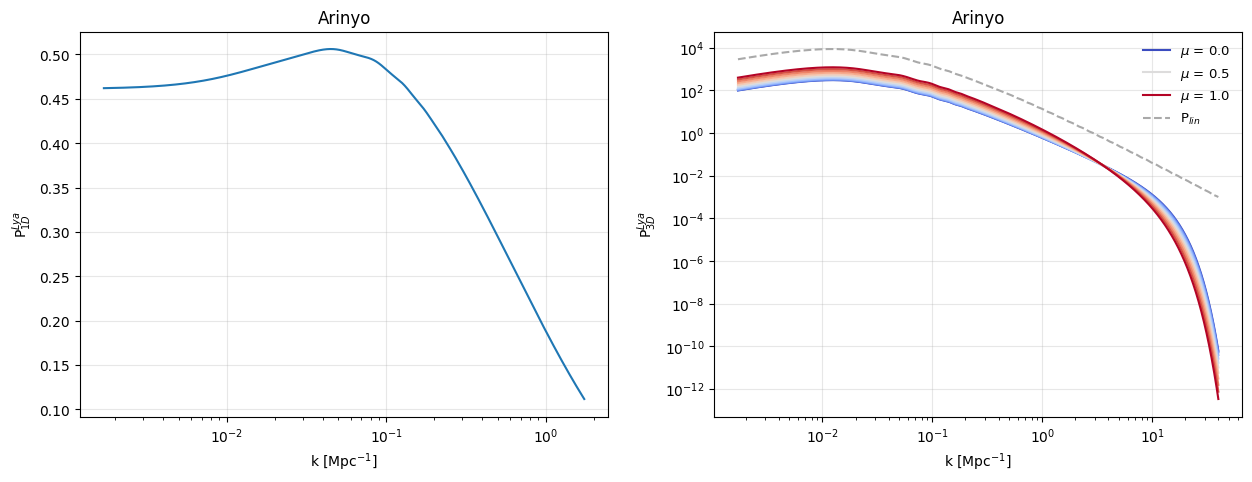

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_los, p1d_arinyo)
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{Lya}$')
plt.title('Arinyo');


plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_arinyo[:, i], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_arinyo[:, i])
plt.plot(k, plin, color='darkgrey', linestyle='--', label=r'P$_{lin}$')
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$')
plt.title('Arinyo');


# P3D Ratio

In [17]:
ratio_MW11 = P3d_hcd_MW11/p3d_arinyo.T
ratio_astrid = P3d_hcd_astrid/p3d_arinyo.T
ratio_vega = P3d_hcd_vega/p3d_arinyo.T

That I need to resample into k_los to compare with Fig. B1 in MW11

In [18]:
k_los_ratio = []
ratio_klos_astrid, ratio_klos_MW11, ratio_klos_vega = [], [], []
for i, mu_value in enumerate(mu):
    k_los_value = k * mu_value
    k_los_ratio.append(k_los_value)
    ratio_klos_astrid.append(ratio_astrid[i, :])
    ratio_klos_MW11.append(ratio_MW11[i, :])
    ratio_klos_vega.append(ratio_vega[i, :])


k_los_ratio = np.array(k_los_ratio)  
ratio_klos_astrid, ratio_klos_MW11, ratio_klos_vega = np.array(ratio_klos_astrid), np.array(ratio_klos_MW11), np.array(ratio_klos_vega) 

/var/folders/4r/vx1gr4gd4p99y59swb8x2lzr0000gn/T/ipykernel_55646/2607915004.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_MW11[i, :], label = '$\mu$ = %.1f' %mu[i])
/var/folders/4r/vx1gr4gd4p99y59swb8x2lzr0000gn/T/ipykernel_55646/2607915004.py:25: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_astrid[i, :], label = '$\mu$ = %.1f' %mu[i])
/var/folders/4r/vx1gr4gd4p99y59swb8x2lzr0000gn/T/ipykernel_55646/2607915004.py:42: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_vega[i, :], label = '$\mu$ = %.1f' %mu[i])


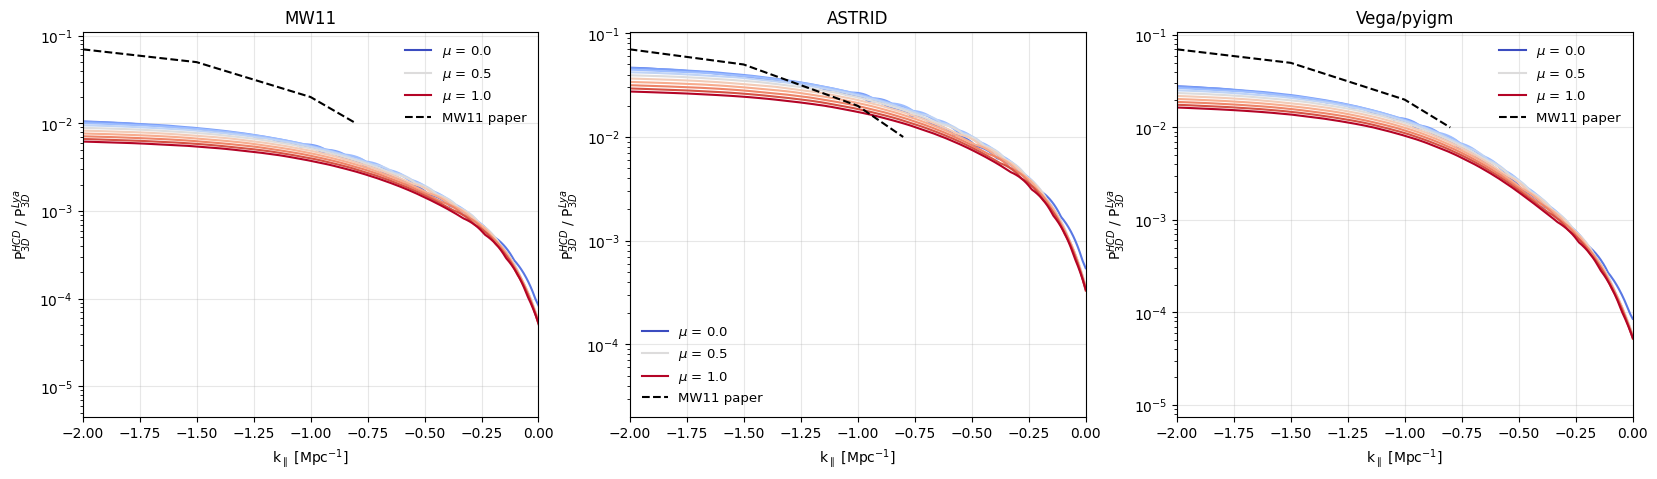

In [19]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_MW11[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_MW11[i, :])
plt.plot([-2, -1.5, -1, -0.8], [0.07, 0.05, 0.02, 0.01], linestyle='--', color='k', label='MW11 paper')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.xlim(-2, 0)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ / P$_{3D}^{Lya}$')
plt.title('MW11');

plt.subplot(1, 3, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_astrid[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_astrid[i, :])
plt.plot([-2, -1.5, -1, -0.8], [0.07, 0.05, 0.02, 0.01], linestyle='--', color='k', label='MW11 paper')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.xlim(-2, 0)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ / P$_{3D}^{Lya}$')
plt.title('ASTRID');

plt.subplot(1, 3, 3)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_vega[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(np.log10(k_los_ratio[i, :]), ratio_klos_vega[i, :])
plt.plot([-2, -1.5, -1, -0.8], [0.07, 0.05, 0.02, 0.01], linestyle='--', color='k', label='MW11 paper')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.xlim(-2, 0)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ / P$_{3D}^{Lya}$')
plt.title('Vega/pyigm');


# P1D ratio

For MW11 we follow their Eq. B1. For ASTRID and Vega, we don't have an w1_term

In [20]:
integral = []
for k_los_value in k_los:
    mu_value_i = k_los_value/k  # Given k_los value, what mu array is associated 
    mask = (mu_value_i > 0.0) & (mu_value_i <= 1)
    mu_value, k_value = mu_value_i[mask], k[mask]
    kperp_value = np.sqrt(k_value**2 - k_los_value**2)
    plin_value = np.interp(k_value, k, plin, right=np.nan, left=np.nan)
    # logarithmic integration
    m = np.log10(kperp_value)
    y = plin_value*((bias_hcd + mu_value**2)**2)*(kperp_value**2)*np.log(10)/(2*np.pi)
    integral.append(np.trapezoid(y, m))

P1d_MW11 = w1_MW11 + (w2_MW11**2)*np.array(integral)
P1d_astrid = (w2_astrid**2)*np.array(integral)
P1d_vega = (w2_vega**2)*np.array(integral)

Using the P1d_arinyo calculated above

In [21]:
ratio_p1d_astrid = P1d_astrid/p1d_arinyo.T
ratio_p1d_MW11 = P1d_MW11/p1d_arinyo.T
ratio_p1d_vega = P1d_vega/p1d_arinyo.T

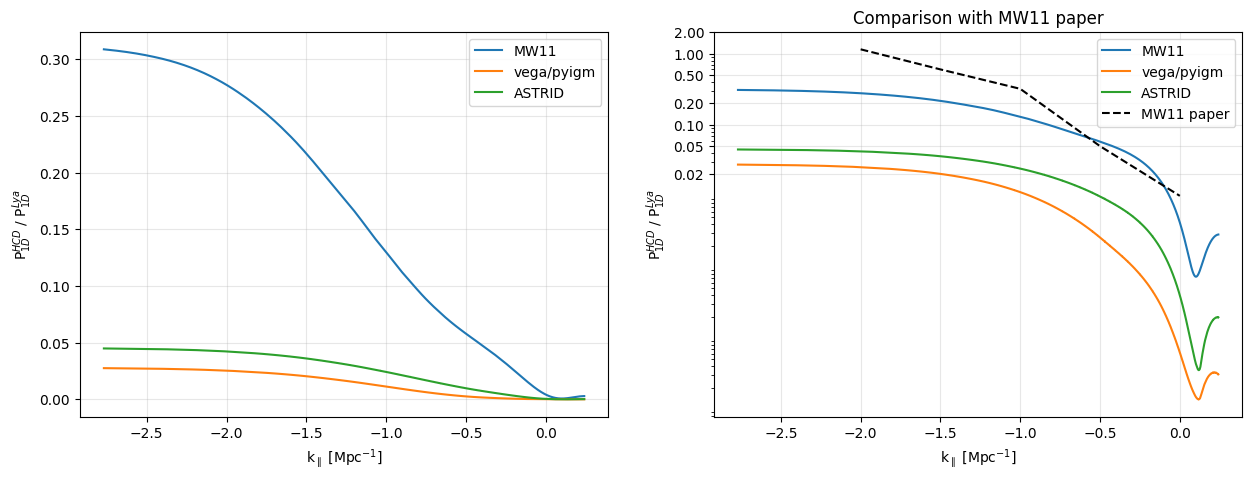

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(np.log10(k_los), ratio_p1d_MW11, label='MW11')
plt.plot(np.log10(k_los), ratio_p1d_vega, label='vega/pyigm')
plt.plot(np.log10(k_los), ratio_p1d_astrid, label='ASTRID')
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{HCD}$ / P$_{1D}^{Lya}$')
plt.grid(alpha=0.3)
plt.legend();

plt.subplot(1, 2, 2)
plt.plot(np.log10(k_los), ratio_p1d_MW11, label='MW11')
plt.plot(np.log10(k_los), ratio_p1d_vega, label='vega/pyigm')
plt.plot(np.log10(k_los), ratio_p1d_astrid, label='ASTRID')
plt.plot([-2, -1.5, -1, -0.5, 0], [0.15+1, 0.1+0.5, 0.02+0.3, 0.05, 0.01], linestyle='--', color='k', label='MW11 paper')
plt.yscale('log')
yticks = np.array([0.02, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00])
plt.yticks(yticks, [f"{y:.2f}" for y in yticks])
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{HCD}$ / P$_{1D}^{Lya}$')
plt.grid(alpha=0.3)
plt.legend()
plt.title('Comparison with MW11 paper');